
**Marcilio Mendonca** - PhD, ML Specialist, Sr. Solutions Architect

Hodwy!

I finally found some time to share this notebook I wrote a while back to teach neural nets from scratch to newbies. It contains the implementation of a nano neural net that learns the Fahrenheit-to-Celsius conversion function. It features forward and backpropagation (gradient descent) algorithm, basic normalization and hyperparameters such as learning rate and number of epochs. Feel free to mess with it, add new layers, change the hyperparameters, etc., and see what happens. That's how we learn!



In [68]:
%pip install matplotlib pillow



[notice] A new release of pip available: 22.2.2 -> 25.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [69]:
import numpy as np
import matplotlib.pyplot as plt

def generate_learning_plot(actual_w, actual_b, learning_w, learning_b, epoch, loss, norm_factor):
    # Generate x values from -40°F to 120°F
    x = np.linspace(-40, 120, 100)
    
    # Calculate corresponding y values in °C
    actual_y = actual_w * x + actual_b
    learning_y = learning_w *  (x / norm_factor) + learning_b

    # Create a new figure and axes with a slightly larger size
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot the lines
    ax.plot(x, actual_y, label='Actual', color='blue')
    ax.plot(x, learning_y, label='Learned', color='red')
    
    # Axis labels and title
    ax.set_xlabel('Fahrenheit (°F)')
    ax.set_ylabel('Celsius (°C)')
    ax.set_title('Fahrenheit to Celsius Nano Neural Net Training')
    
    # Legend and annotation
    ax.legend()
    ax.text(0.05, 0.95, f'Epoch: {epoch}, Loss: {loss:.4f}, w: {learning_w}, b: {learning_b}',
            transform=ax.transAxes, verticalalignment='top')
    
    # Reference lines and grid
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.grid(True)

    # Fixed axis ranges
    ax.set_xlim(-40, 120)
    ax.set_ylim(-40, 50)

    return fig


In [70]:
# Neural Net Training Algorithm - Forward + Backprop

from typing import List
def train(x: List[float], y: List[float], num_epochs: int = 10, learn_rate: float = 0.001, norm_factor: float = 100.0, callback = None):
    print("Training started")
    # ideally initialize w randomly
    w, b, x = 5.0, 0.0, [i/norm_factor for i in x]
    for epoch in range(num_epochs):
        tl = 0
        for i in range(len(x)):
            z = w * x[i] + b
            l = ( y[i] - z ) ** 2
            tl += l
            dl_dz, dz_dw = -2 * ( y[i] - z ), x[i]
            dl_dw, dl_db = dl_dz * dz_dw, dl_dz * 1
            w, b = w - learn_rate * dl_dw, b - learn_rate * dl_db
        if callback:
            callback(w, b, epoch, l, norm_factor)
    return w,b

# Prediction - note the use normalization since that's how we trained the network
def predict(x: List[float], w: float, b: float, norm_factor: float = 100.0):
    return [w * (xi/norm_factor) + b for xi in x]


Training started
- Epoch: 000, Loss: 1076.4220
- Epoch: 220, Loss: 344.6635
- Epoch: 440, Loss: 130.3171
- Epoch: 660, Loss: 50.4483
- Epoch: 880, Loss: 19.5925
- Epoch: 1100, Loss: 7.6131
- Epoch: 1320, Loss: 2.9589
- Epoch: 1540, Loss: 1.1503
- Epoch: 1760, Loss: 0.4474
- Epoch: 1980, Loss: 0.1741
[-17.59892512020171, -17.59892512020171]
[12.716507263070376, -23.11082191716027]


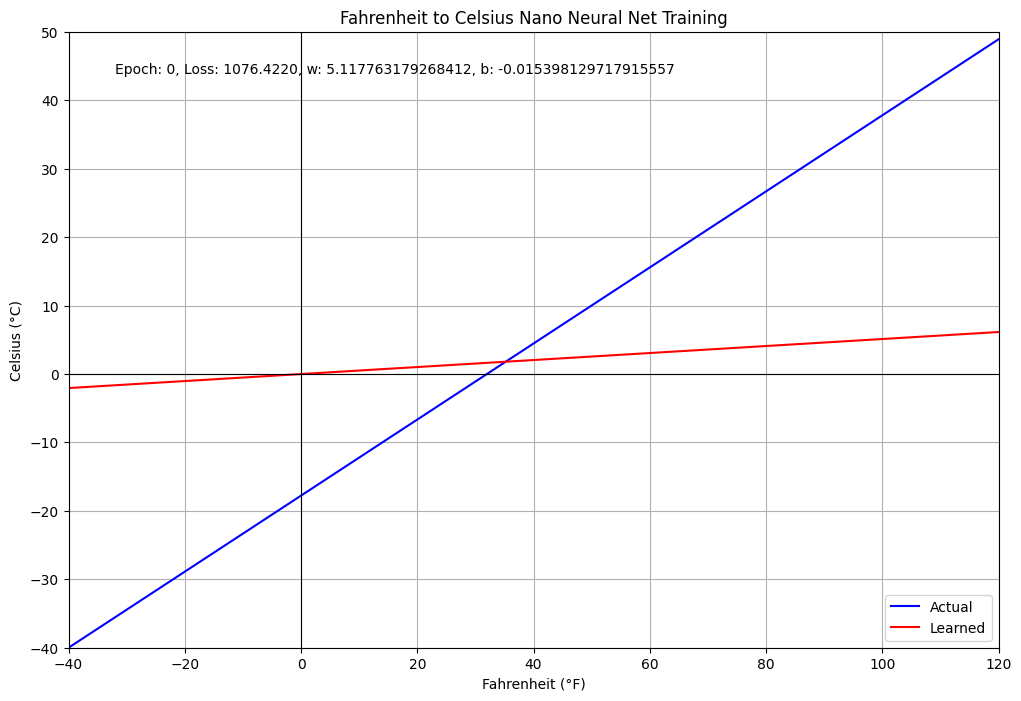

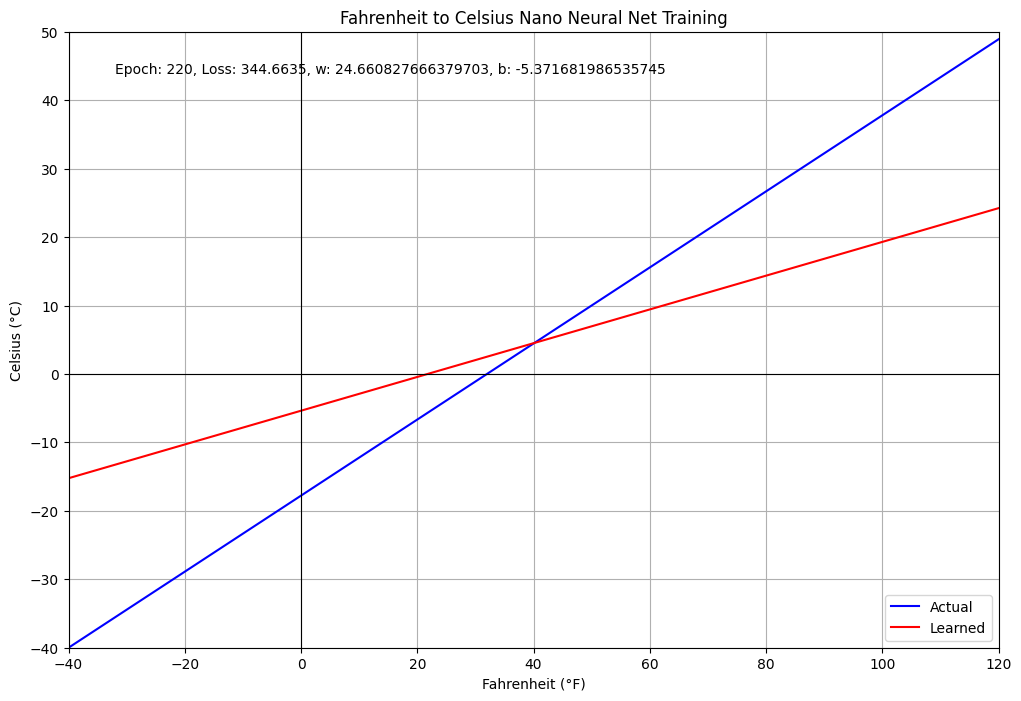

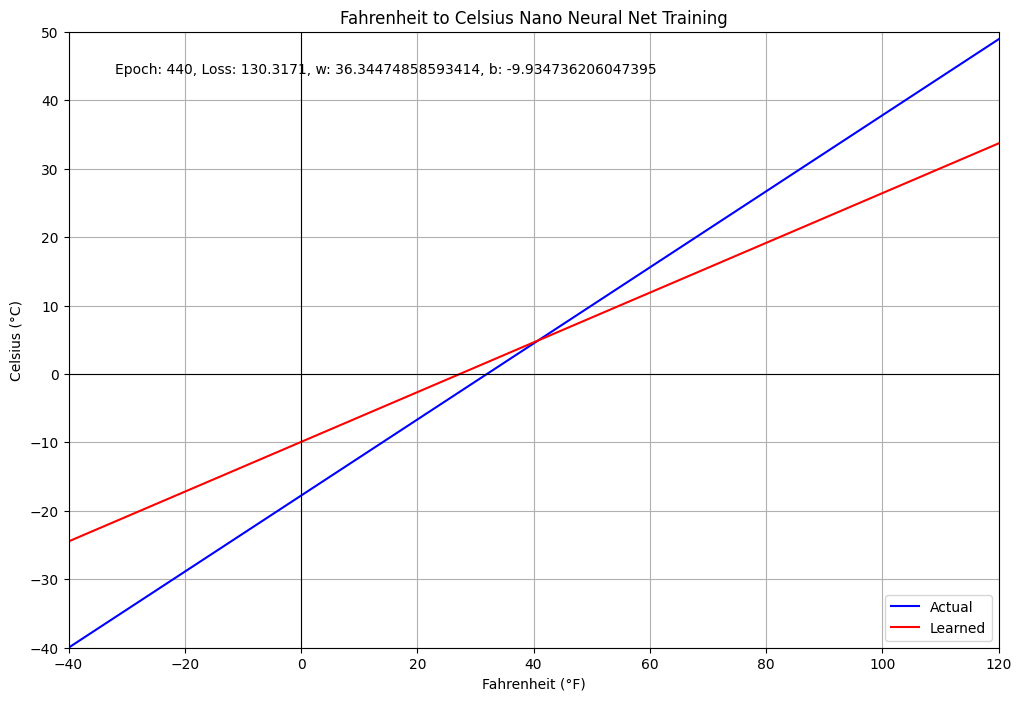

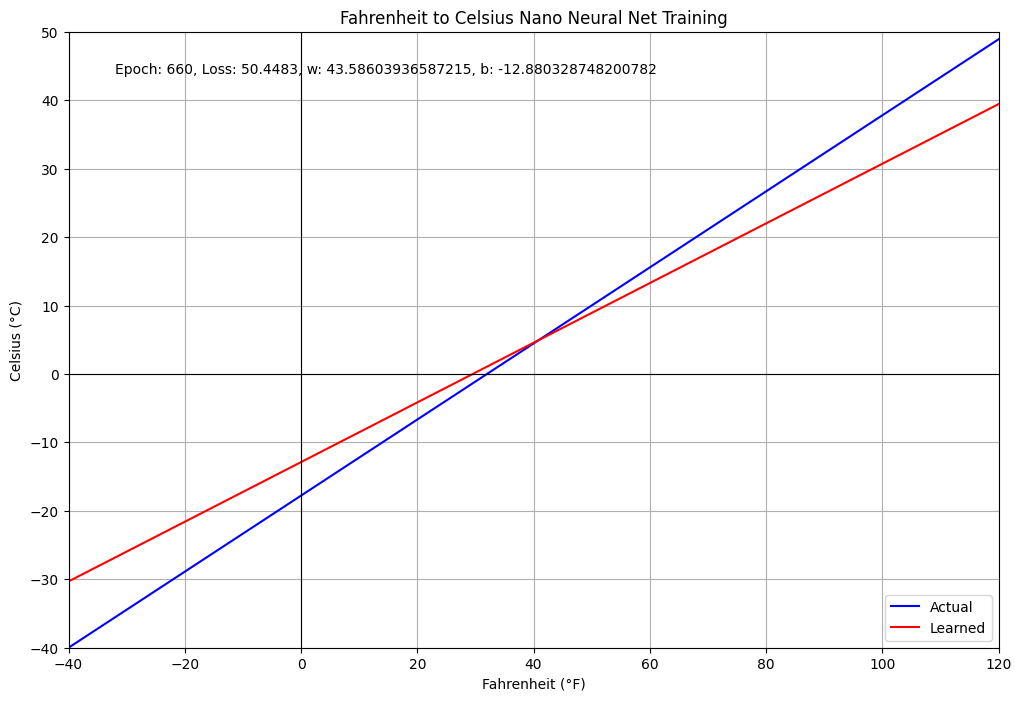

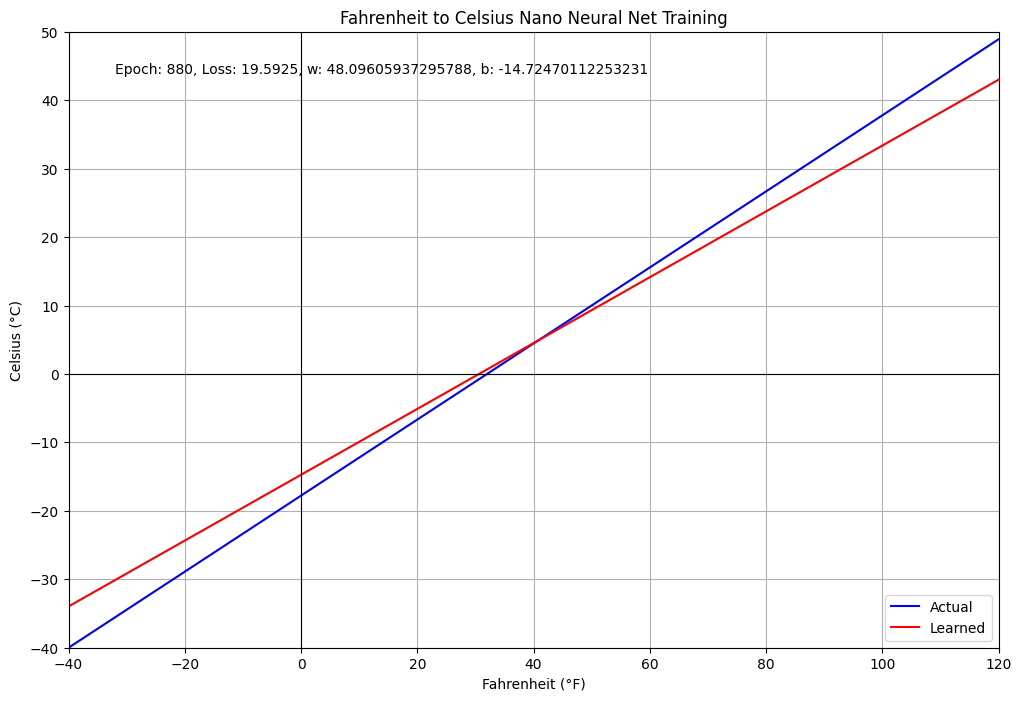

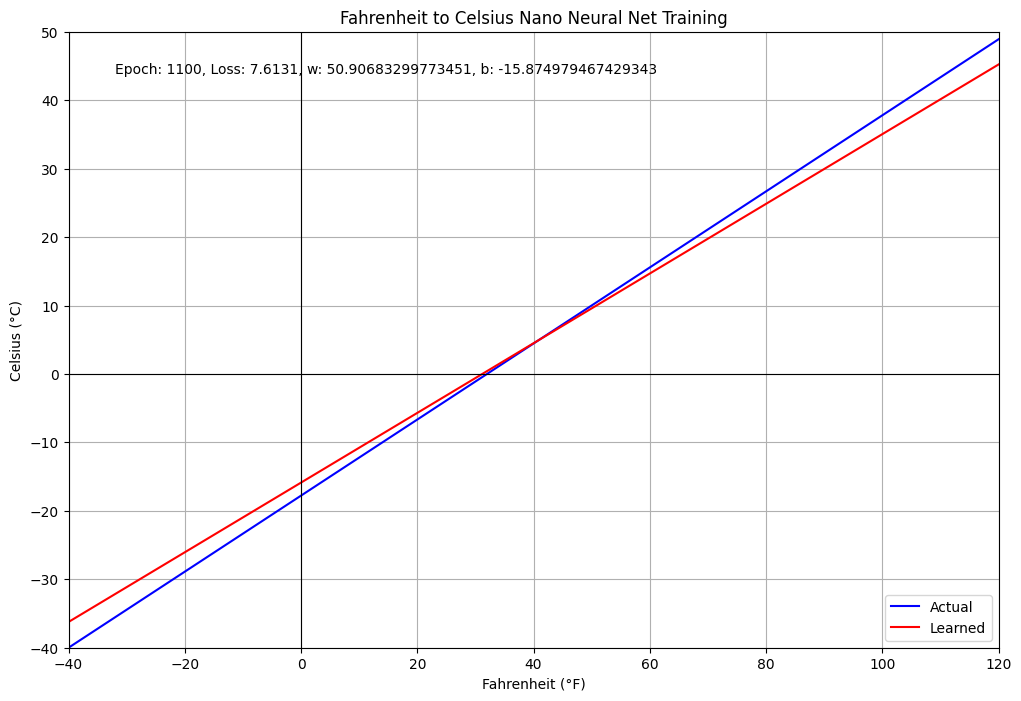

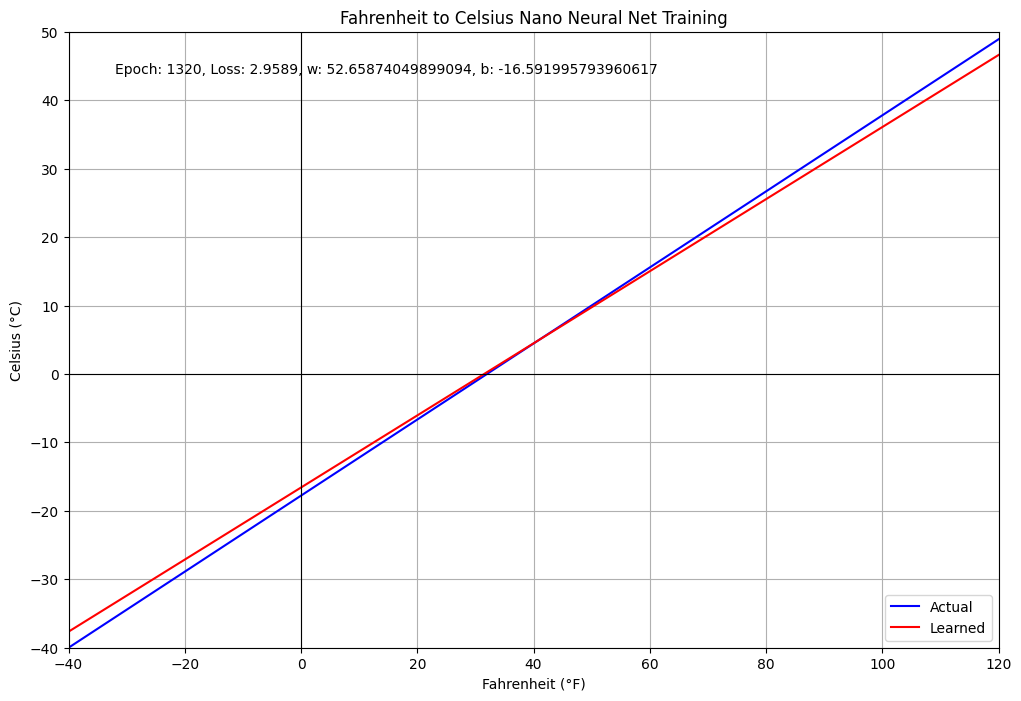

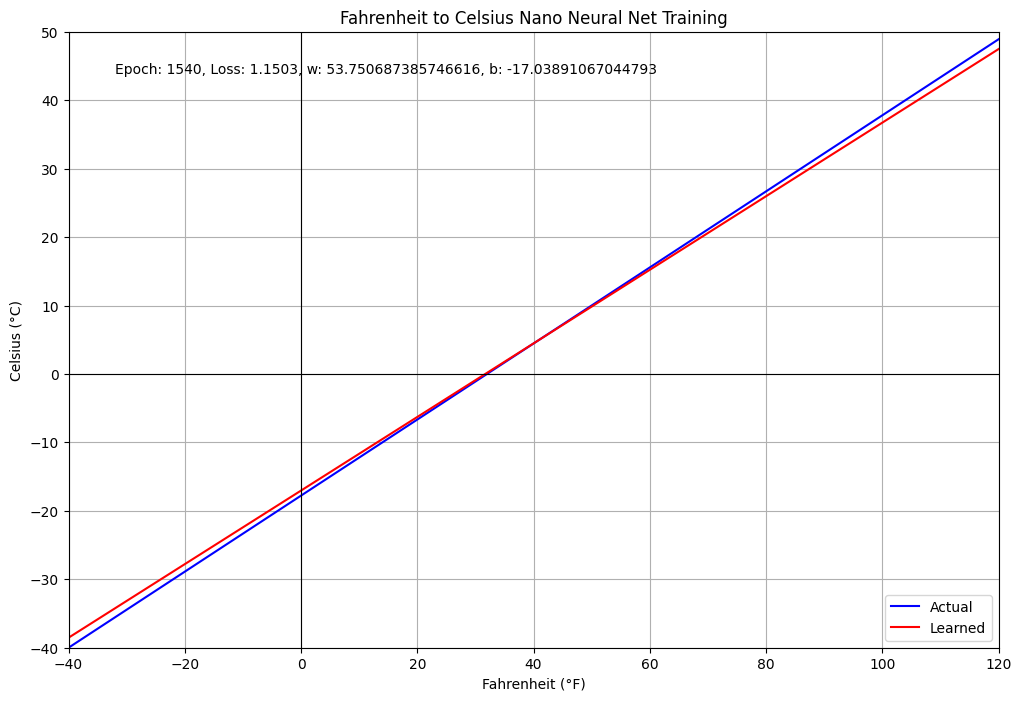

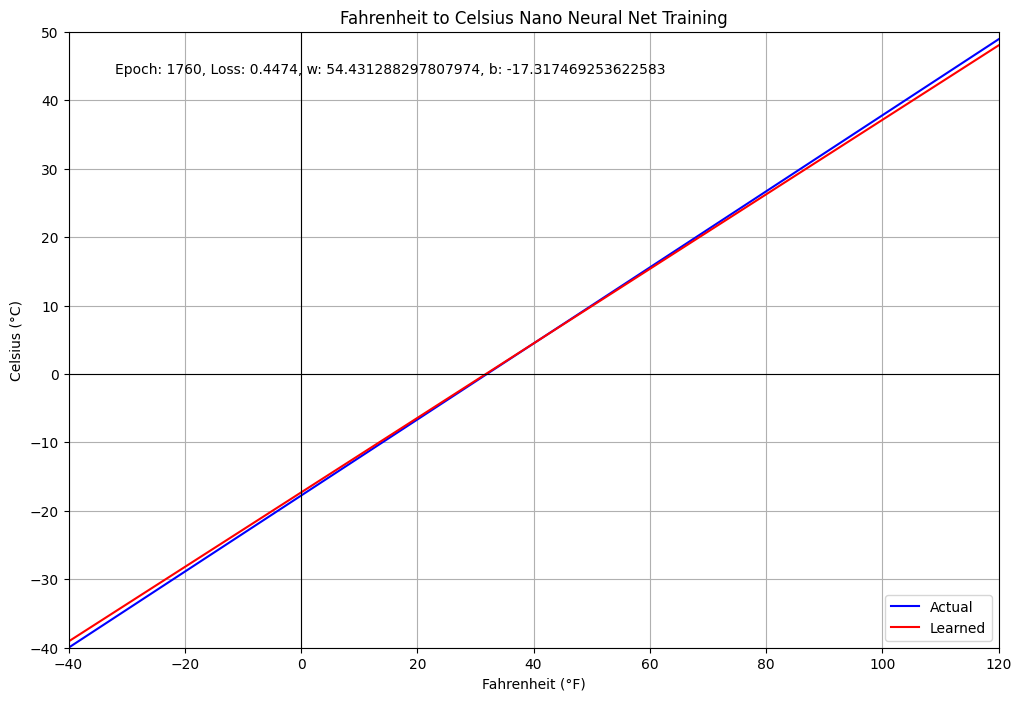

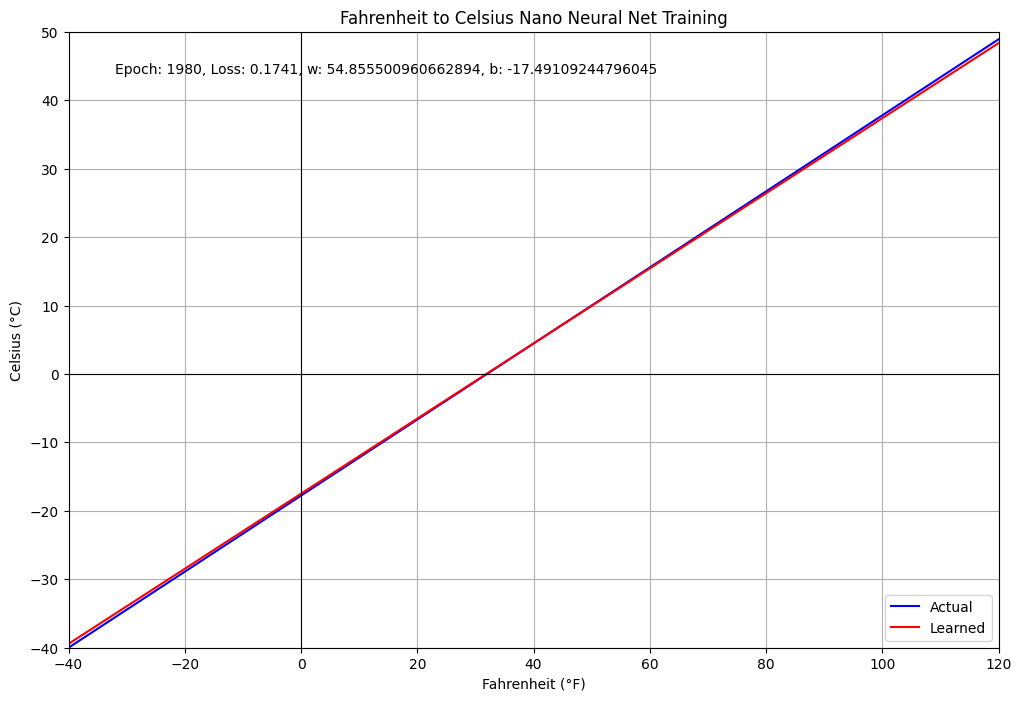

In [77]:

# hyperparametes
epochs = 2200
learning_rate = 0.001
norm_factor = 100

# actual F to C conversion function's slope and intercept 
actual_w = 0.5556
actual_b = -17.7778

# plots to watch the learning process
plot_sampling = int(epochs/(10))
sample_plots = []

# generate the plots
def viz_callback(learned_w, learned_b, epoch, loss, norm_factor):
    if epoch % plot_sampling == 0:
        plot = generate_learning_plot(actual_w, actual_b, learned_w, learned_b, epoch, loss, norm_factor)
        print(f"- Epoch: {epoch:03d}, Loss: {loss:.4f}")
        sample_plots.append((epoch, plot))

w, b, = train([-40, 0, 32, 68, 100], [-40.0, -17.78, 0.0, 20.0, 37.78], num_epochs=epochs,learn_rate=learning_rate, norm_factor=norm_factor, callback=viz_callback)

# save plots
for epoch, plot in sample_plots:
    plot.savefig(f"plots/plot_epoch_{epoch:07d}.png")

# let's test some predictions
print(predict([0, 0], w, b)) # 32.0C, -17.78C
print(predict([55, -10], w, b)) # 12.78C, -23.33


Animation saved to animation.gif


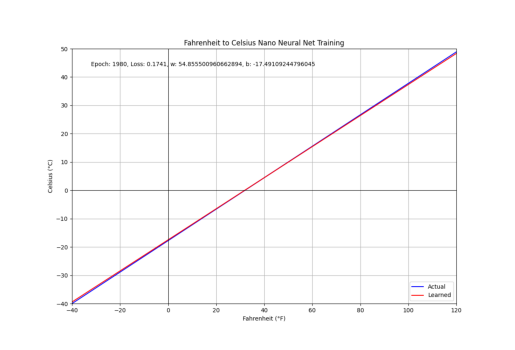

In [ ]:
# Generate a quick animation

import os
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from PIL import Image

def create_png_animation(input_folder, output_file='learning_animation.gif', interval=0.5):
    # Get list of PNG images and sort them
    image_files = sorted(
        [f for f in os.listdir(input_folder) if f.lower().endswith('.png')]
    )

    # Load images
    images = [Image.open(os.path.join(input_folder, f)) for f in image_files]

    # Create a figure
    fig = plt.figure()
    plt.axis('off')  # hide axes

    ims = []
    for img in images:
        im = plt.imshow(img, animated=True)
        ims.append([im])

    # Create animation (interval in milliseconds)
    ani = animation.ArtistAnimation(fig, ims, interval=interval * 1000, repeat_delay=1000)

    # Save animation as GIF
    ani.save(output_file, writer='pillow')

    print(f"Animation saved to {output_file}")

# Example usage:
create_png_animation('plots/')

